# Explore here

In [ ]:
# Your code here
# cargar dataset
import pandas as pd

url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=";") # Nota: este dataset suele usar punto y coma

# Visualización inicial
print(df.head())
print(df.info())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [2]:
#analisis exploratorio (EDA) y preprocesamiento de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# se convierte la variable objetivo a numérica
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# se separan variables predictoras (X) y objetivo (y)
X = df.drop('y', axis=1)
y = df['y']

# se codifican variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# se divide en Train y Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
#contruir el modelo de regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [4]:
# Optimización, mejorando el Recall para la clase minoritaria (1)
# Optimizamos usando class_weight='balanced'
model_opt = LogisticRegression(class_weight='balanced', max_iter=1000)
model_opt.fit(X_train_scaled, y_train)

# Nuevas predicciones
y_pred_opt = model_opt.predict(X_test_scaled)

# Comparar este reporte con el anterior
print("--- Reporte Optimizado (Balanceado) ---")
print(classification_report(y_test, y_pred_opt))

# hay que checar la matriz para ver los cambios
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred_opt))

--- Reporte Optimizado (Balanceado) ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      7303
           1       0.45      0.90      0.60       935

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.92      0.86      0.88      8238

--- Matriz de Confusión ---
[[6262 1041]
 [  98  837]]


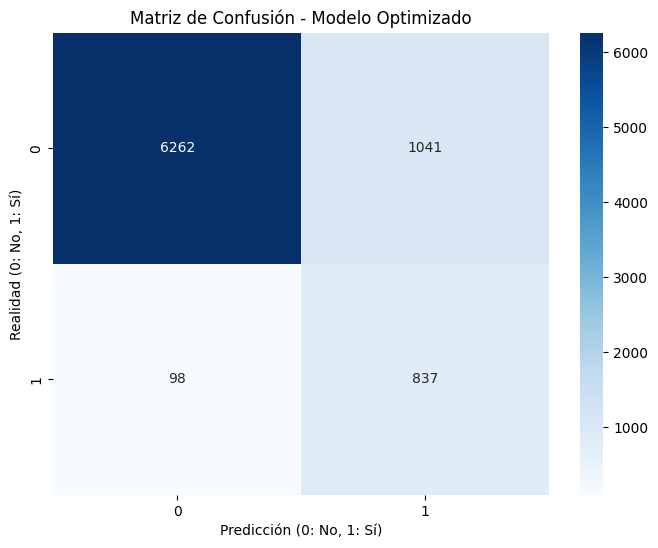

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.xlabel('Predicción (0: No, 1: Sí)')
plt.ylabel('Realidad (0: No, 1: Sí)')
plt.show()

## Analisis estadistico descriptivo 

In [6]:
# Estadísticas descriptivas para variables numéricas
print(df.describe())

# Para variables categóricas (objetos)
print(df.describe(include='object'))


               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m  \
count  41188.000000    41188.000000   41188.000000  41188.000000   
mean       0.081886       93.575664     -40.502600      3.621291   
std        1.570960        0.578840       4.628198      1.734447   
min       -3.400000      

/tmp/ipykernel_1016/223911671.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


## Analisis de la variable objetivo

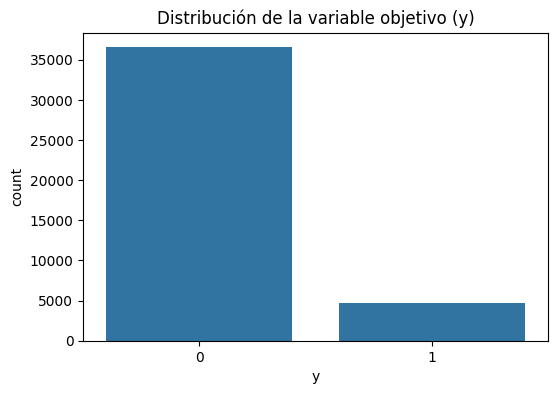

y
0    88.734583
1    11.265417
Name: proportion, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')
plt.title('Distribución de la variable objetivo (y)')
plt.show()

# Ver el porcentaje exacto
print(df['y'].value_counts(normalize=True) * 100)

## Análisis Univariante (Visualización)

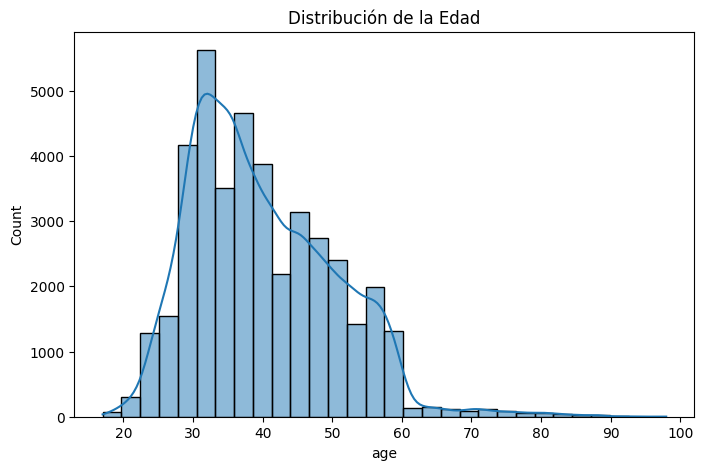

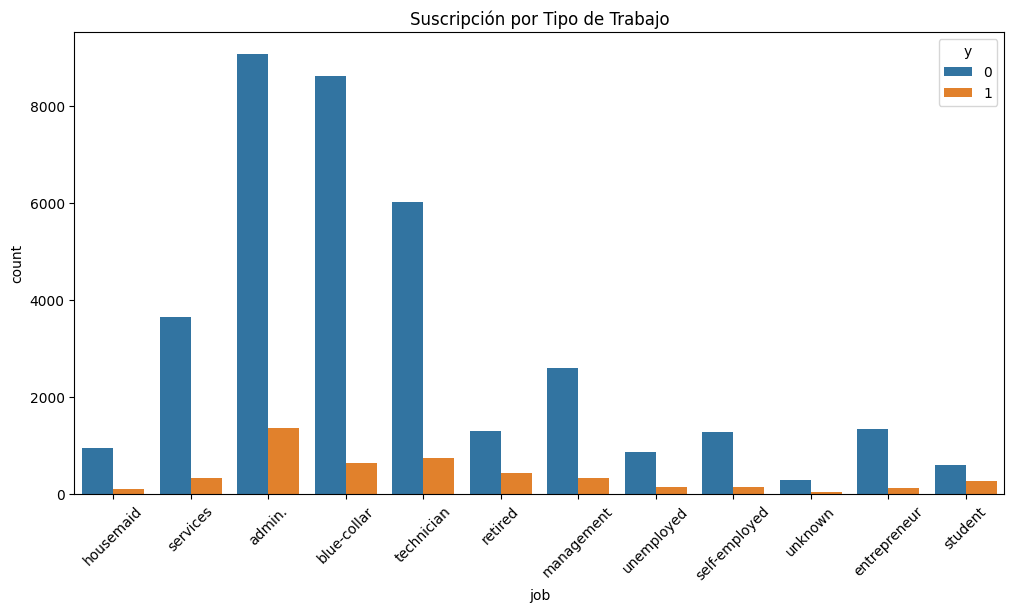

In [8]:
# Distribución de la edad
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Distribución de la Edad')
plt.show()

# Relación entre Trabajo y la suscripción (y)
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='job', hue='y')
plt.xticks(rotation=45)
plt.title('Suscripción por Tipo de Trabajo')
plt.show()

## Analisis de correlación para variables numéricas

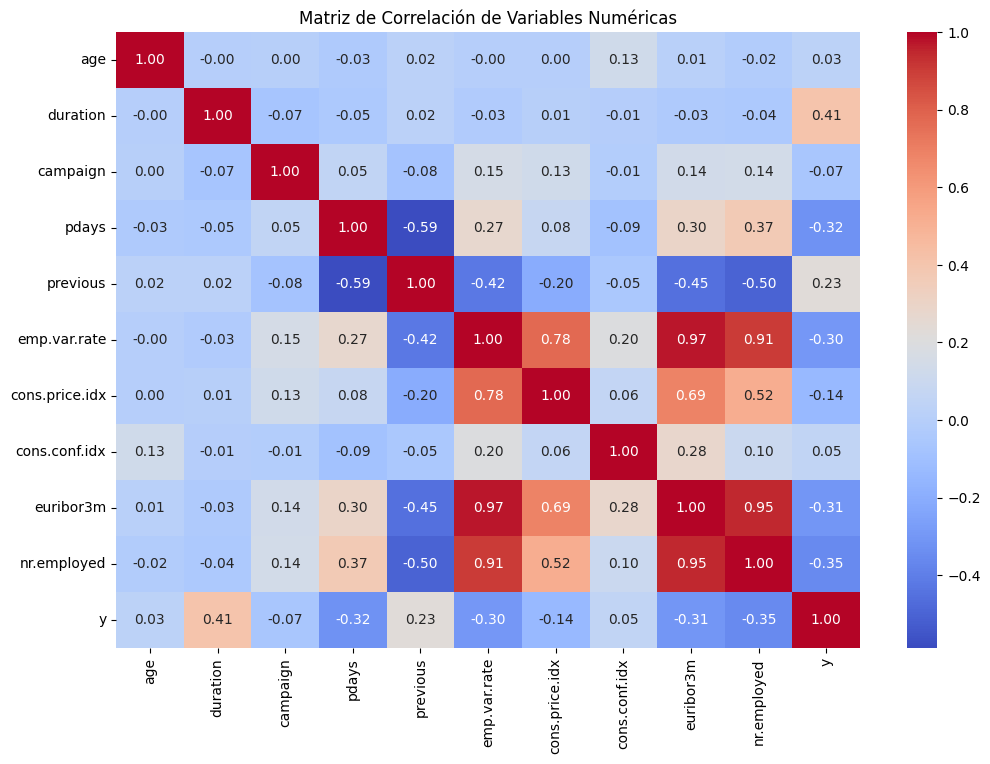

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

## Limpieza de Datos (Data Cleaning)

In [10]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Verificar duplicados
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")

# Si hay duplicados, elimínalos
# df = df.drop_duplicates()

Valores nulos por columna:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Número de filas duplicadas: 12


## Análisis de Outliers (Valores atípicos)

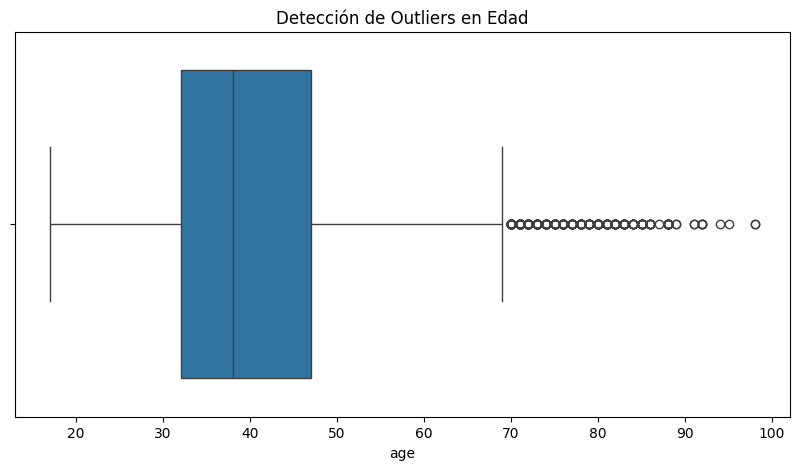

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['age'])
plt.title('Detección de Outliers en Edad')
plt.show()